### A Gentle Introduction to Machine Learning with Python and Scikit-learn

##### Setting the environment

In [1]:
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import IPython
import platform

#Show the versions we will be using 
print ('Python version:', platform.python_version())
print ('IPython version:', IPython.__version__)
print ('numpy version:', np.__version__)
print ('scikit-learn version:', sklearn.__version__)
print ('matplotlib version:', matplotlib.__version__)
    

Python version: 3.13.9
IPython version: 9.7.0
numpy version: 2.3.5
scikit-learn version: 1.7.2
matplotlib version: 3.10.6


##### Loading Dataset

In [2]:
from sklearn import datasets

iris = datasets.load_iris()
x_iris = iris.data
y_iris = iris.target

In [3]:
print(x_iris.shape, y_iris.shape)

print("Features names:{0}".format(iris.feature_names))
print("Target classes:{0}".format(iris.target_names))
print("First instance features:{0}".format(x_iris[0]))

(150, 4) (150,)
Features names:['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes:['setosa' 'versicolor' 'virginica']
First instance features:[5.1 3.5 1.4 0.2]


#### Display each instance in a 2d-scatter plot, using first sepal measures, and then petal measures

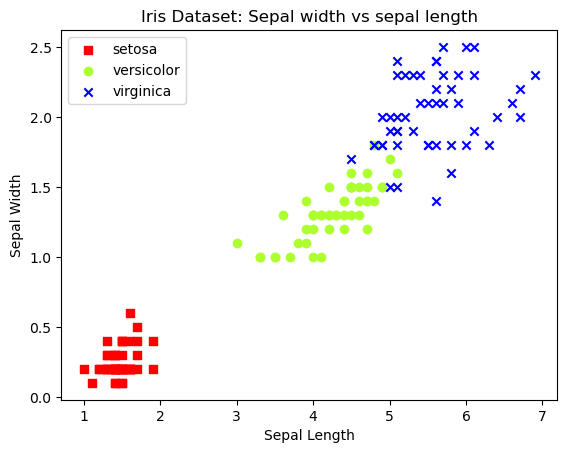

In [5]:
# 2D display for sepal measurements
plt.figure("sepal")
colormarkers = [["red","s"],["greenyellow","o"],["blue","x"]]
for i in range(len(colormarkers)):
    px = x_iris[:, 2][y_iris == i]
    py = x_iris[:, 3][y_iris == i]
    plt.scatter(px, py, c=colormarkers[i][0], marker=colormarkers[i][1])

plt.title("Iris Dataset: Sepal width vs sepal length")
plt.legend(iris.target_names)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()  

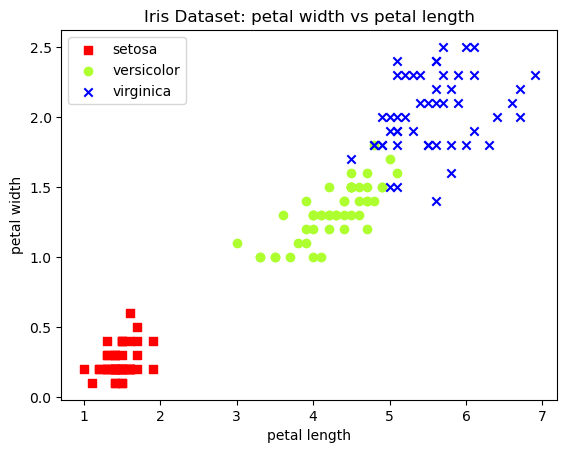

In [6]:
## 2D display of petal measurements

plt.figure("petal")
colormarkers = [["red","s"],["greenyellow","o"], ["blue", "x"]]
for i in range(len(colormarkers)):
    px = x_iris[:,2][y_iris==i]
    py = x_iris[:,3][y_iris==i]
    plt.scatter(px,py, c=colormarkers[i][0], marker=colormarkers[i][1])

plt.title("Iris Dataset: petal width vs petal length")
plt.legend(iris.target_names)
plt.xlabel("petal length")
plt.ylabel("petal width")
plt.show()

#### Supervised Learning: Classification

#### Separate training and testing sets

In [7]:
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# create dataset with two attributes
x,y = x_iris[:,[0,1]], y_iris

# test set will be 25% taken randomly
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.25, random_state =33)

# standardize the features
scaler = preprocessing.StandardScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

##### Check mean and standard deviation after scaling

In [8]:
print ("Training Set Mean:{:.2f} and Standard Deviation:{:.2f}".format(np.average(x_train), np.std(x_train)))

print("Testing Sets Mean:{:.2f} and Standard Deviation:{:.2f}".format(np.average(x_test), np.std(x_test)))

Training Set Mean:0.00 and Standard Deviation:1.00
Testing Sets Mean:0.13 and Standard Deviation:0.71


#### Display The Traning data after scaling

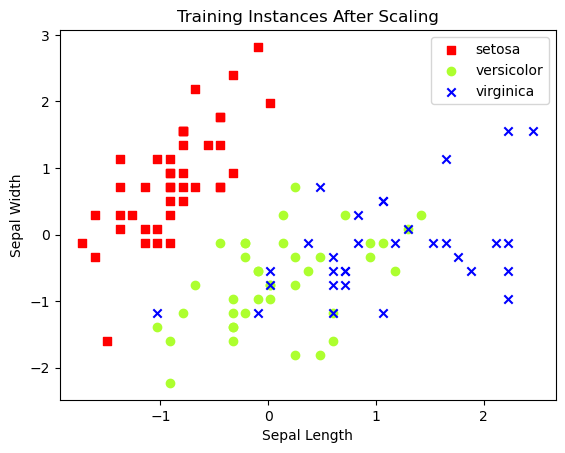

In [9]:
colormarkers = [["red", "s"], ["greenyellow", "o"], ["blue", "x"]]

plt.figure("Training Data")
for i in range (len(colormarkers)):
    xs = x_train[:,0][y_train==i]
    ys = x_train[:,1][y_train==i]
    plt.scatter(xs,ys, c=colormarkers[i][0], marker=colormarkers[i][1])

plt.title("Training Instances After Scaling")
plt.legend(iris.target_names)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()


#### Linear , Binary Classifier

In [10]:
import copy
# Every 1 and 2 classes in training will be just 1
y_train_setosa = copy.copy(y_train)
y_train_setosa[y_train_setosa> 0]=1
y_test_setosa = copy.copy(y_test)
y_test_setosa[y_test_setosa> 0]=1

print("New Training Target Classes:\n{0}".format(y_train_setosa))

New Training Target Classes:
[1 0 1 1 1 0 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 1 0 0 1 1 0
 1 1 1 1 0 1 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 0 1 1
 0 0 0 0 1 1 0 1 1 1 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1 1
 0]


In [11]:
from sklearn import linear_model
clf = linear_model.SGDClassifier(loss="log_loss", random_state=42)
print(clf)

SGDClassifier(loss='log_loss', random_state=42)


##### call the fit method to train the classifier

In [12]:
clf.fit(x_train, y_train_setosa)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [13]:
print(clf.coef_,clf.intercept_)

[[ 21.76180381 -10.51985217]] [13.90763024]


#### Draw decision boundary using pyplot

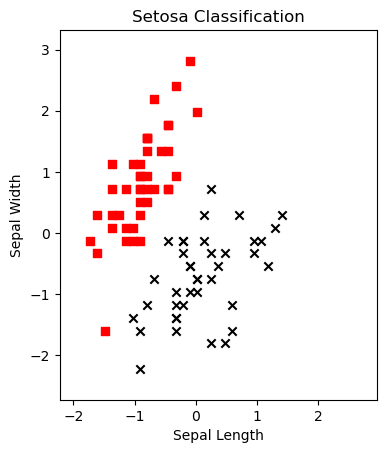

In [14]:
x_min, x_max = x_train[:,0].min()-.5, x_train[:,0].max()+.5
y_min, y_max = x_train[:,1].min()-.5, x_train[:,1].max()+.5

xs = np.arange(x_min, x_max, 0.5)
fig,axes = plt.subplots()

axes.set_aspect("equal")
axes.set_title("Setosa Classification")
axes.set_xlabel("Sepal Length")
axes.set_ylabel("Sepal Width")
axes.set_xlim(x_min, x_max)
axes.set_ylim(y_min, y_max)

plt.sca(axes)
plt.scatter(x_train[:,0][y_train==0], x_train[:,1][y_train==0],c="red", marker="s")
plt.scatter(x_train[:,0][y_train==1], x_train[:,1][y_train==1],c="black", marker="x")

ys = (-clf.intercept_[0]-xs * clf.coef_[0, 0]/clf.coef_[0, 1])
plt.plot(xs,ys,)
plt.show()

#### Prediction

In [15]:
print("If the flower has 4.7 petal width and 3.1 petal length is a {}".format(
    iris.target_names[clf.predict(scaler.transform([[4.7, 3.1]]))]))

If the flower has 4.7 petal width and 3.1 petal length is a ['setosa']


#### Back to the original three-class problem

In [16]:
clf2 = linear_model.SGDClassifier(loss="log_loss", random_state=33)
clf2.fit(x_train, y_train)
print(len(clf2.coef_))

3


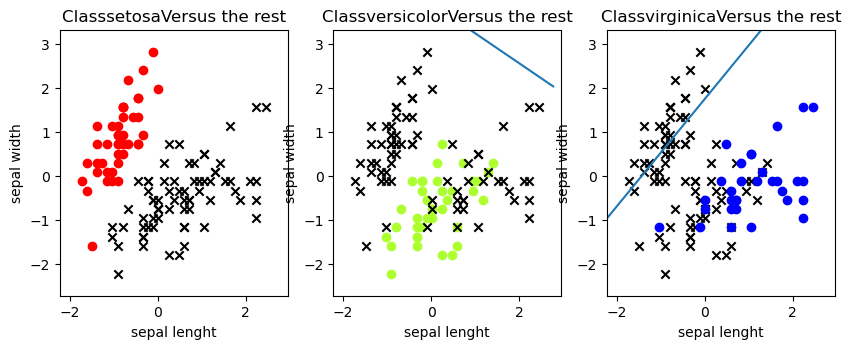

In [20]:
x_min, x_max = x_train[:,0].min()-.5, x_train[:,0].max()+.5
y_min, y_max = x_train[:,1].min()-.5, x_train[:,1].max()+.5
xs = np.arange(x_min, x_max, 0.5)
fig, axes = plt.subplots(1,3)
fig.set_size_inches(10,6)
for i in [0,1,2]:
    axes[i].set_aspect("equal")
    axes[i].set_title("Class"+ iris.target_names[i]+ "Versus the rest")
    axes[i].set_xlabel("sepal lenght")
    axes[i].set_ylabel("sepal width")
    axes[i].set_xlim(x_min, x_max)
    axes[i].set_ylim(y_min, y_max)
    plt.sca(axes[i])
    ys=(-clf2.intercept_[i]-xs*clf2.coef_[i,0]/clf2.coef_[i,1])
    plt.plot(xs,ys)
    for j in [0,1,2]:
        px = x_train[:,0][y_train==j]
        py = x_train[:,1][y_train==j]
        color = colormarkers[j][0] if j==i else "black"
        marker = "o" if j==i else "x"
        plt.scatter(px, py, c=color, marker=marker)
plt.show()
    

In [21]:
scaler.transform([[4.7,3.1]])
print(clf2.decision_function(scaler.transform([[4.7,3.1]])))
clf2.predict(scaler.transform([[4.7,3.1]]))

[[12.28099231 -1.90098209 -5.11974221]]


array([0])

#### Evaluating the classifier

In [22]:
from sklearn import metrics
y_train_pred = clf2.predict(x_train)
print("Accuracy on the training set:{:.2f}".format(metrics.accuracy_score(y_train, y_train_pred)))

Accuracy on the training set:0.69


In [23]:
y_pred = clf2.predict(x_test)
print("Accuracy on the testing set:{:.2f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy on the testing set:0.71


In [24]:
print(metrics.confusion_matrix(y_test, y_pred))

[[ 8  0  0]
 [ 0  0 11]
 [ 0  0 19]]


In [26]:
print(metrics.classification_report(y_test, y_pred, target_names=iris.target_names, zero_division=0))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.00      0.00      0.00        11
   virginica       0.63      1.00      0.78        19

    accuracy                           0.71        38
   macro avg       0.54      0.67      0.59        38
weighted avg       0.53      0.71      0.60        38



#### Using the four flower attributes

In [28]:
# Test set will be the 25% taken randomly
x_train4, x_test4, y_train4, y_test4 = train_test_split(x_iris, y_iris, test_size=0.25, random_state=33)
    
# Standarize the features
scaler = preprocessing.StandardScaler().fit(x_train4)
x_train4 = scaler.transform(x_train4)
x_test4 = scaler.transform(x_test4)

# Build the classifier
clf3 = linear_model.SGDClassifier(loss="log_loss", random_state=33)
clf3.fit(x_train4, y_train4) 

# Evaluate the classifier on the evaluation set
y_pred4 = clf3.predict(x_test4)
print (metrics.classification_report(y_test4, y_pred4, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      0.73      0.84        11
   virginica       0.86      1.00      0.93        19

    accuracy                           0.92        38
   macro avg       0.95      0.91      0.92        38
weighted avg       0.93      0.92      0.92        38



#### Unsupervised Learning: Clustering

In [36]:
#  Now import your modules
from sklearn import cluster

#  Run your code
clf_sepal = cluster.KMeans(init="k-means++", n_clusters=3, random_state=33)
clf_sepal.fit(x_train4[:, 0:2])

C:\Users\kkc29\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,33
,copy_x,True
,algorithm,'lloyd'


In [38]:
print(clf_sepal.labels_)

[0 1 0 0 2 1 1 0 1 2 1 1 0 2 1 2 0 2 0 2 1 0 2 1 1 2 1 0 2 2 2 0 1 1 2 0 1
 0 2 2 2 1 2 1 0 1 2 2 1 2 0 1 1 2 1 1 1 2 2 1 0 1 0 1 0 2 0 0 0 1 0 1 2 2
 1 1 1 1 2 2 1 0 0 2 0 1 1 0 0 0 1 0 0 1 2 0 2 0 2 1 2 1 1 1 0 0 2 0 0 0 2
 1]


In [39]:
print(y_train4[clf_sepal.labels_==0])

[1 1 1 1 1 2 1 0 1 2 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 1 2 1]


In [40]:
print(y_train4[clf_sepal.labels_==2])

[1 2 2 1 2 1 2 2 2 2 2 1 2 1 2 2 2 1 2 2 2 2 1 1 2 2 2 2 2 2 2 1 2 2]


In [43]:

colormarkers = [ ["red","s"], ["greenyellow","o"], ["blue","x"]]
step = .01 
margin = .1   
sl_min, sl_max = x_train4[:, 0].min()-margin, x_train4[:, 0].max() + margin
sw_min, sw_max = x_train4[:, 1].min()-margin, x_train4[:, 1].max() + margin
sl, sw  = np.meshgrid(
    np.arange(sl_min, sl_max, step),
np.arange(sw_min, sw_max, step)
    )
Zs = clf_sepal.predict(np.c_[sl.ravel(), sw.ravel()]).reshape(sl.shape)
centroids_s = clf_sepal.cluster_centers_

In [44]:
from sklearn import cluster

# 1. Initialize KMeans for petal dimensions
clf_petal = cluster.KMeans(init="k-means++", n_clusters=3, random_state=33)

# 2. Fit the model using the petal features (Petal length [index 2] and Petal width [index 3])
clf_petal.fit(x_train4[:, 2:4])

print("clf_petal successfully created and fitted!")

clf_petal successfully created and fitted!


C:\Users\kkc29\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


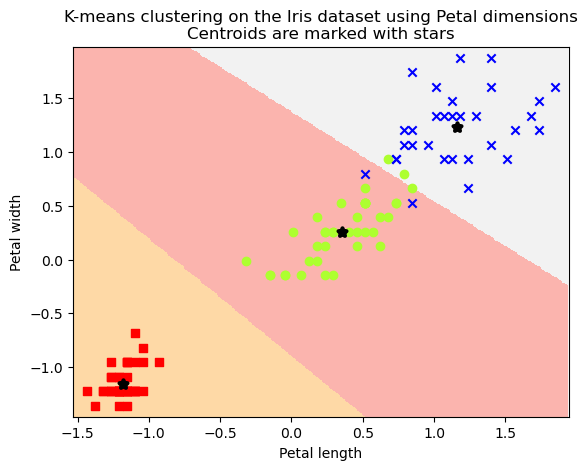

In [45]:
#Display the data points and the calculated regions
colormarkers = [ ["red","s"], ["greenyellow","o"], ["blue","x"]]
step = .01 
margin = .1
sl_min, sl_max = x_train4[:, 2].min()-margin, x_train4[:, 2].max() + margin
sw_min, sw_max = x_train4[:, 3].min()-margin, x_train4[:, 3].max() + margin
sl, sw  = np.meshgrid(
    np.arange(sl_min, sl_max, step),
    np.arange(sw_min, sw_max, step), 
    )
zs = clf_petal.predict(np.c_[sl.ravel(), sw.ravel()]).reshape(sl.shape)
centroids_s = clf_petal.cluster_centers_
plt.figure(1)
plt.clf()
plt.imshow(zs, interpolation="nearest", extent=(sl.min(), sl.max(), sw.min(), sw.max()), cmap= plt.cm.Pastel1, aspect="auto", origin="lower")
for j in [0,1,2]:
    px = x_train4[:, 2][y_train4 == j]
    py = x_train4[:, 3][y_train4 == j]
    plt.scatter(px, py, c=colormarkers[j][0], marker= colormarkers[j][1])
plt.scatter(centroids_s[:, 0], centroids_s[:, 1],marker="*",linewidths=3, color="black", zorder=10)
plt.title("K-means clustering on the Iris dataset using Petal dimensions\nCentroids are marked with stars")
plt.xlim(sl_min, sl_max)
plt.ylim(sw_min, sw_max)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.show()

####  calculate the clusters, using the four attributes

In [47]:
clf = cluster.KMeans(init='k-means++', n_clusters=3, random_state=33)
clf.fit(x_train4)

C:\Users\kkc29\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,33
,copy_x,True
,algorithm,'lloyd'


In [48]:
print (y_train[clf.labels_==0])

[1 1 1 1 1 1 1 0 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 1 1 1]


In [49]:
print (y_train[clf.labels_==1])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0]


In [50]:
print (y_train[clf.labels_==2])

[2 2 1 2 2 1 2 2 1 2 2 2 1 2 1 2 2 2 1 2 2 2 2 2 1 1 2 2 2 2 2 2 2 1 2 2 2]


In [51]:

y_pred=clf.predict(x_test4)
print (metrics.classification_report(y_test, y_pred, target_names=['setosa','versicolor','virginica']))

              precision    recall  f1-score   support

      setosa       0.00      0.00      0.00         8
  versicolor       0.00      0.00      0.00        11
   virginica       0.79      0.79      0.79        19

    accuracy                           0.39        38
   macro avg       0.26      0.26      0.26        38
weighted avg       0.39      0.39      0.39        38



#### Supervised Learning: Regression

In [59]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print("California dataset shape: {}".format(housing.data.shape))

California dataset shape: (20640, 8)


In [60]:
print (housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [61]:
from sklearn import preprocessing

x_train_housing = housing.data
y_train_housing = housing.target

# Scale features (housing.data is already a 2D array)
x_train_housing = preprocessing.StandardScaler().fit_transform(x_train_housing)

# Reshape y_train_housing to 2D before scaling, then flatten back if needed
scaler_y = preprocessing.StandardScaler()
y_train_housing = scaler_y.fit_transform(y_train_housing.reshape(-1, 1)).ravel()

print("X shape:", x_train_housing.shape)
print("y shape:", y_train_housing.shape)

X shape: (20640, 8)
y shape: (20640,)


#### Create a method for training and evaluating a model.

In [64]:
from sklearn.model_selection import KFold, cross_val_score

def train_and_evaluate(clf, x_train, y_train, folds):
    clf.fit(x_train, y_train)
    print("Score on training set: {:.2f}".format(clf.score(x_train, y_train)))
    
    # Create a k-fold cross-validation iterator using model_selection
    cv = KFold(n_splits=folds, shuffle=True, random_state=33)
    scores = cross_val_score(clf, x_train, y_train, cv=cv)
    
    print("Average score using {}-fold cross-validation: {:.2f}".format(folds, np.mean(scores)))

In [67]:

from sklearn import linear_model
clf_sgd = linear_model.SGDRegressor(loss="squared_error", penalty=None, random_state=33)
train_and_evaluate(clf_sgd, x_train_housing, y_train_housing,5)

Score on training set: -5817.55
Average score using 5-fold cross-validation: -15302479.59


In [68]:

print(clf_sgd.coef_)

[  2.82869062  -7.59627786  -8.90809095   4.65186671 -12.49678834
 -74.31321964  -0.26359573   1.07501089]


In [69]:
from sklearn import linear_model
clf_sgd1 = linear_model.SGDRegressor(loss="squared_error", penalty="l2", random_state=33)
train_and_evaluate(clf_sgd1, x_train_housing, y_train_housing, folds=5)

Score on training set: -5722.70
Average score using 5-fold cross-validation: -15093226.69


### END OF NOTEBOOK BY PETER OWILI